# 03 — Baseline CNN

Train a small convolutional network from scratch for binary real-vs-AI image classification. The standard experiment uses the fixed train, validation, and test splits created in notebook 01.

## Setup

Load the reusable data, model, training, and evaluation utilities. The test split remains unused until the best epoch has been selected using validation loss.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW


def find_repo_root(start: Path) -> Path:
    """Find the repository root from the current working directory."""
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config
from src.data.loaders import create_dataloaders
from src.evaluation import evaluate_predictions, save_evaluation_outputs
from src.models import BaselineCNN, count_trainable_parameters
from src.training import fit, set_seed

In [2]:
config: dict = load_config()
SEED: int = config["seed"]
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MANIFEST_PATH = REPO_ROOT / "data" / "dataset.csv"
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
CHECKPOINT_PATH = REPO_ROOT / "results" / "models" / "baseline_cnn" / "best_model.pt"
METRICS_ROOT = REPO_ROOT / "results" / "metrics" / "baseline_cnn"
FIGURES_ROOT = REPO_ROOT / "results" / "figures" / "baseline_cnn"
METRICS_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

Device: cpu


## DataLoaders

Use deterministic transforms for the first baseline. Training is shuffled with the project seed, while validation and test retain stable order.

In [3]:
loader_config = config["dataloader"]
dataloaders = create_dataloaders(
    manifest=MANIFEST_PATH,
    processed_root=PROCESSED_ROOT,
    batch_size=loader_config["batch_size"],
    num_workers=loader_config["num_workers"],
    seed=SEED,
    pin_memory=device.type == "cuda",
)

print("Dataset sizes:", {split: len(loader.dataset) for split, loader in dataloaders.items()})
sample_batch = next(iter(dataloaders["train"]))
print("Image batch shape:", tuple(sample_batch["image"].shape))
print("Label batch shape:", tuple(sample_batch["label"].shape))
print("Pixel range:", float(sample_batch["image"].min()), float(sample_batch["image"].max()))

Dataset sizes: {'train': 9800, 'val': 2100, 'test': 2100}
Image batch shape: (32, 3, 224, 224)
Label batch shape: (32,)
Pixel range: -1.0 1.0


## Model

The baseline has four Conv–BatchNorm–ReLU–MaxPool blocks, global average pooling, dropout, and one output logit. `BCEWithLogitsLoss` applies the sigmoid operation internally.

In [4]:
model_config = config["baseline_cnn"]
model = BaselineCNN(
    channels=tuple(model_config["channels"]),
    dropout=model_config["dropout"],
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(
    model.parameters(),
    lr=model_config["learning_rate"],
    weight_decay=model_config["weight_decay"],
)

with torch.inference_mode():
    sample_logits = model(sample_batch["image"].to(device))

print(f"Trainable parameters: {count_trainable_parameters(model):,}")
print("Logit shape:", tuple(sample_logits.shape))
assert sample_logits.shape == sample_batch["label"].shape

Trainable parameters: 389,153
Logit shape: (32,)


## Train and select the best epoch

Only train and validation data are used here. Early stopping monitors validation loss and restores the best checkpoint when training finishes.

In [5]:
fit_result = fit(
    model=model,
    train_dataloader=dataloaders["train"],
    val_dataloader=dataloaders["val"],
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=model_config["epochs"],
    patience=model_config["early_stopping_patience"],
    min_delta=model_config["early_stopping_min_delta"],
    checkpoint_path=CHECKPOINT_PATH,
)

history = pd.DataFrame(fit_result.history)
history.to_csv(METRICS_ROOT / "training_history.csv", index=False)
print(f"Best epoch: {fit_result.best_epoch}")
print(f"Best validation loss: {fit_result.best_val_loss:.4f}")
history

Epoch 01/20 | train loss 0.6623, F1 0.6326 | val loss 0.5895, F1 0.6371
Epoch 02/20 | train loss 0.6002, F1 0.6754 | val loss 0.5575, F1 0.6952
Epoch 03/20 | train loss 0.5763, F1 0.6933 | val loss 0.5559, F1 0.7499
Epoch 04/20 | train loss 0.5612, F1 0.7108 | val loss 0.5401, F1 0.7347
Epoch 05/20 | train loss 0.5413, F1 0.7242 | val loss 0.5243, F1 0.7301
Epoch 06/20 | train loss 0.5309, F1 0.7304 | val loss 0.5037, F1 0.7526
Epoch 07/20 | train loss 0.5269, F1 0.7396 | val loss 0.5042, F1 0.7561
Epoch 08/20 | train loss 0.5166, F1 0.7479 | val loss 0.5308, F1 0.7477
Epoch 09/20 | train loss 0.5102, F1 0.7527 | val loss 0.5526, F1 0.6588
Epoch 10/20 | train loss 0.5049, F1 0.7499 | val loss 0.5030, F1 0.7698
Epoch 11/20 | train loss 0.4983, F1 0.7599 | val loss 0.4832, F1 0.7600
Epoch 12/20 | train loss 0.4958, F1 0.7569 | val loss 0.4856, F1 0.7473
Epoch 13/20 | train loss 0.4920, F1 0.7622 | val loss 0.4966, F1 0.7489
Epoch 14/20 | train loss 0.4849, F1 0.7657 | val loss 0.4816, F1

,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.662321,0.626224,0.621968,0.643673,0.632635,0.674138,0.589483,0.676190,0.724515,0.568571,0.637140,0.753143
1,2,0.600202,0.675816,0.676284,0.674490,0.675386,0.741977,0.557484,0.698095,0.701942,0.688571,0.695192,0.784372
2,3,0.576318,0.692755,0.692011,0.694694,0.693350,0.766340,0.555919,0.708095,0.655960,0.875238,0.749898,0.813780
3,4,0.561152,0.710408,0.709894,0.711633,0.710762,0.781538,0.540082,0.729048,0.719635,0.750476,0.734732,0.801810
4,5,0.541345,0.723878,0.723422,0.724898,0.724159,0.800456,0.524321,0.730952,0.732502,0.727619,0.730053,0.812582
5,6,0.530915,0.731020,0.732158,0.728571,0.730360,0.809044,0.503657,0.741429,0.721397,0.786667,0.752620,0.830686
6,7,0.526904,0.736837,0.731961,0.747347,0.739574,0.812672,0.504175,0.741905,0.716724,0.800000,0.756076,0.834216
7,8,0.516556,0.745714,0.741573,0.754286,0.747875,0.821789,0.530772,0.725238,0.691188,0.814286,0.747704,0.816902
8,9,0.510214,0.750510,0.746239,0.759184,0.752656,0.826413,0.552642,0.726190,0.874016,0.528571,0.658754,0.836845
9,10,0.504900,0.748265,0.745114,0.754694,0.749873,0.830723,0.502975,0.754762,0.725358,0.820000,0.769781,0.836636


## Learning curves

Compare train and validation loss and F1 to identify convergence and overfitting.

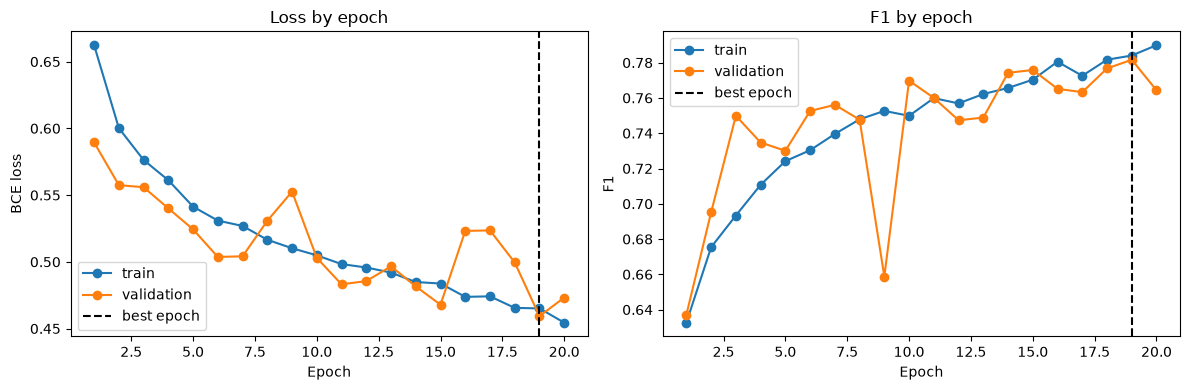

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="validation")
axes[0].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_f1"], marker="o", label="train")
axes[1].plot(history["epoch"], history["val_f1"], marker="o", label="validation")
axes[1].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[1].set_title("F1 by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_ROOT / "training_curves.png", dpi=150)
plt.show()

## Final test evaluation

Evaluate the restored best checkpoint once on the previously untouched test split. Save overall metrics, individual predictions, per-generator metrics, the confusion matrix, and the ROC curve.

In [7]:
test_result = evaluate_predictions(
    model=model,
    dataloader=dataloaders["test"],
    criterion=criterion,
    device=device,
    threshold=0.5,
)
saved_paths = save_evaluation_outputs(
    test_result, output_dir=METRICS_ROOT, figures_dir=FIGURES_ROOT
)

print("Test metrics:")
display(pd.Series(test_result.metrics.to_dict(), name="value"))
print("Per-generator metrics:")
display(test_result.per_generator)
print("Saved outputs:")
for name, path in saved_paths.items():
    print(f"  {name}: {path.relative_to(REPO_ROOT)}")

Test metrics:


loss         0.427600
accuracy     0.796190
precision    0.789033
recall       0.808571
f1           0.798683
roc_auc      0.887641
Name: value, dtype: float64

Per-generator metrics:


,generator,n_ai,n_real,accuracy,precision,recall,f1,roc_auc
0,adm,150,150,0.853333,0.776042,0.993333,0.871345,0.995200
1,biggan,150,150,0.906667,0.842697,1.000000,0.914634,0.982222
2,glide,150,150,0.890000,0.819672,1.000000,0.900901,0.954800
3,midjourney,150,150,0.640000,0.723404,0.453333,0.557377,0.722222
4,sdv1_5,150,150,0.753333,0.743590,0.773333,0.758170,0.851111
5,vqdm,150,150,0.753333,0.801587,0.673333,0.731884,0.853333
6,wukong,150,150,0.776667,0.782313,0.766667,0.774411,0.878889


Saved outputs:
  metrics: results\metrics\baseline_cnn\test_metrics.json
  predictions: results\metrics\baseline_cnn\test_predictions.csv
  per_generator: results\metrics\baseline_cnn\per_generator_metrics.csv
  confusion_matrix: results\figures\baseline_cnn\confusion_matrix.png
  roc_curve: results\figures\baseline_cnn\roc_curve.png


In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
checkpoint["best_epoch"] = fit_result.best_epoch
checkpoint["config"] = model_config
checkpoint["test_metrics"] = test_result.metrics.to_dict()
torch.save(checkpoint, CHECKPOINT_PATH)

print(f"Model saved to: {CHECKPOINT_PATH.relative_to(REPO_ROOT)}")

Model saved to: results\models\baseline_cnn\best_model.pt
